In [ ]:
# CELL 0 — installing
!pip install datasets yfinance pandas numpy -q

import pandas as pd
import numpy as np
import yfinance as yf
import re
import os
from datasets import load_dataset

print("All libraries ready!")

All libraries ready!


In [ ]:
# CELL 1 —  all text datasets collection
# SOURCE 1: Twitter financial sentiment
# SOURCE 2: Financial news classification
# SOURCE 3: Auditor sentiment (Financial PhraseBank)

print("Loading Dataset 1 — Twitter Financial Sentiment...")
d1 = load_dataset("zeroshot/twitter-financial-news-sentiment", split="train")
df1 = pd.DataFrame(d1)
df1['sentiment_label'] = df1['label'].map({0:'negative', 1:'positive', 2:'neutral'})
df1 = df1.rename(columns={'text': 'tweet'})
df1['source'] = 'twitter'
df1 = df1[['tweet', 'sentiment_label', 'source']]
print(f"Twitter: {len(df1):,} rows")

print("\nLoading Dataset 2 — Financial Classification...")
d2 = load_dataset("nickmuchi/financial-classification", split="train")
df2 = pd.DataFrame(d2)
df2['sentiment_label'] = df2['labels'].map({0:'negative', 1:'positive'})
df2 = df2.rename(columns={'text': 'tweet'})
df2['source'] = 'financial_news'
df2 = df2[['tweet', 'sentiment_label', 'source']]
print(f"Financial News: {len(df2):,} rows")

print("\nLoading Dataset 3 — Auditor Sentiment...")
d3 = load_dataset("FinanceInc/auditor_sentiment", split="train")
df3 = pd.DataFrame(d3)
df3['sentiment_label'] = df3['label'].map({0:'negative', 1:'neutral', 2:'positive'})
df3 = df3.rename(columns={'sentence': 'tweet'})
df3['source'] = 'financial_phrasebank'
df3 = df3[['tweet', 'sentiment_label', 'source']]
print(f"Auditor Sentiment: {len(df3):,} rows")

# Combined all 3
df_text = pd.concat([df1, df2, df3], ignore_index=True)
print(f"\nTotal text rows: {len(df_text):,}")
print(df_text['sentiment_label'].value_counts())

Loading Dataset 1 — Twitter Financial Sentiment...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

sent_train.csv: 0.00B [00:00, ?B/s]

sent_valid.csv: 0.00B [00:00, ?B/s]

...

data/train-00000-of-00001.parquet:   0%|          | 0.00/327k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/80.9k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3877 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/969 [00:00<?, ? examples/s]

Auditor Sentiment: 3,877 rows

Total text rows: 17,971
sentiment_label
neutral     8498
positive    5676
negative    2523
Name: count, dtype: int64


In [ ]:
# CELL 2 — Reuters news — for REAL dates
print("Loading Reuters news (306,242 articles)...")
dataset = load_dataset("ashraq/financial-news-articles", split="train")
df_reuters = pd.DataFrame(dataset)
print(f"Loaded: {len(df_reuters):,} articles")

# real dates extraction from article text
def extract_date(text):
    if not isinstance(text, str): return None
    pattern = r'(January|February|March|April|May|June|July|'\
              r'August|September|October|November|December|'\
              r'Jan|Feb|Mar|Apr|Jun|Jul|Aug|Sep|Oct|Nov|Dec)'\
              r'\s+\d{1,2},?\s+\d{4}'
    match = re.search(pattern, text)
    if match:
        try: return pd.to_datetime(match.group(), errors='coerce')
        except: return None
    return None

print("Extracting dates... (2 mins)")
df_reuters['date'] = df_reuters['text'].apply(extract_date)
df_reuters = df_reuters[df_reuters['date'].notna()].copy()
df_reuters['date'] = pd.to_datetime(df_reuters['date']).dt.normalize()
print(f"Articles with real dates: {len(df_reuters):,}")
print(f"Date range: {df_reuters['date'].min()} to {df_reuters['date'].max()}")

Loading Reuters news (306,242 articles)...


README.md:   0%|          | 0.00/543 [00:00<?, ?B/s]

data/train-00000-of-00002-a3f58f0eb179f9(…):   0%|          | 0.00/238M [00:00<?, ?B/s]

data/train-00001-of-00002-50e0d6558d1357(…):   0%|          | 0.00/255M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/306242 [00:00<?, ? examples/s]

Loaded: 306,242 articles
Extracting dates... (2 mins)
Articles with real dates: 123,309
Date range: 1775-04-19 00:00:00 to 2108-04-16 00:00:00


In [ ]:
# CELL 3 — Cleaning text and calculating sentiment scores
# positiveness and negativeness are separate scores

def clean_text(text):
    if not isinstance(text, str): return ""
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text.lower()

pos_words = ['rise','gain','profit','growth','beat','surge','strong',
             'record','success','rally','boost','increase','positive',
             'higher','grew','improved','exceeded','bullish','soar',
             'jump','climb','advance','recover','outperform']

neg_words = ['fall','loss','decline','drop','miss','plunge','crash',
             'weak','fail','cut','layoff','bankruptcy','decrease',
             'lower','fell','missed','bearish','sink','tumble',
             'slump','downturn','recession','deficit','warning']

def get_positiveness(text):
    """Score 0 to 1 — how positive is this text"""
    if not isinstance(text, str): return 0.0
    t = text.lower()
    pos_count = sum(1 for w in pos_words if w in t)
    total = len(t.split())
    return round(min(pos_count / max(total * 0.1, 1), 1.0), 4)

def get_negativeness(text):
    """Score 0 to 1 — how negative is this text"""
    if not isinstance(text, str): return 0.0
    t = text.lower()
    neg_count = sum(1 for w in neg_words if w in t)
    total = len(t.split())
    return round(min(neg_count / max(total * 0.1, 1), 1.0), 4)

def get_sentiment_label(pos, neg):
    if pos > neg: return 'positive'
    elif neg > pos: return 'negative'
    return 'neutral'

print("Cleaning and scoring text...")
df_reuters['tweet'] = df_reuters['text'].apply(clean_text)
df_reuters = df_reuters.drop_duplicates(subset=['tweet'])
df_reuters = df_reuters[df_reuters['tweet'].str.len() > 30]

df_reuters['positiveness'] = df_reuters['tweet'].apply(get_positiveness)
df_reuters['negativeness'] = df_reuters['tweet'].apply(get_negativeness)
df_reuters['sentiment_label'] = df_reuters.apply(
    lambda r: get_sentiment_label(r['positiveness'], r['negativeness']), axis=1
)
df_reuters['source'] = 'reuters'

print(f"Clean Reuters articles: {len(df_reuters):,}")
print(df_reuters['sentiment_label'].value_counts())

Cleaning and scoring text...
Clean Reuters articles: 122,822
sentiment_label
positive    54288
neutral     36951
negative    31583
Name: count, dtype: int64


In [ ]:
# CELL 4 — Matching articles to companies
# Stock-specific news → that stock only
# General market news → all 6 stocks

stocks = ['AAPL','TSLA','GOOGL','AMZN','MSFT','CRM']

stock_keywords = {
    'AAPL':  ['apple','iphone','ipad','tim cook','aapl','macbook','app store'],
    'TSLA':  ['tesla','elon musk','tsla','cybertruck','gigafactory','model 3'],
    'GOOGL': ['google','alphabet','googl','youtube','waymo','android','gemini'],
    'AMZN':  ['amazon','amzn','aws','jeff bezos','prime','alexa'],
    'MSFT':  ['microsoft','msft','azure','satya nadella','windows','copilot'],
    'CRM':   ['salesforce','crm','benioff','dreamforce','slack','tableau'],
}

general_keywords = [
    'federal reserve','fed rate','interest rate','inflation','market rally',
    'stock market','wall street','nasdaq','s&p 500','dow jones','economy',
    'recession','gdp','unemployment','treasury','bond yield','earnings'
]

def classify_article(text):
    if not isinstance(text, str): return ['ALL']
    t = text.lower()
    matched = [s for s, kws in stock_keywords.items()
               if any(kw in t for kw in kws)]
    if matched: return matched
    if any(kw in t for kw in general_keywords): return ['ALL']
    return ['ALL']

print("Classifying articles by company...")
df_reuters['companies'] = df_reuters['tweet'].apply(classify_article)

for stock in stocks:
    count = df_reuters['companies'].apply(
        lambda x: stock in x and x != ['ALL']
    ).sum()
    print(f"  {stock} specific: {count:,}")

general = df_reuters['companies'].apply(lambda x: x == ['ALL']).sum()
print(f"  General market: {general:,}")

Classifying articles by company...
  AAPL specific: 3,058
  TSLA specific: 983
  GOOGL specific: 3,561
  AMZN specific: 28,031
  MSFT specific: 2,332
  CRM specific: 626
  General market: 88,954


In [ ]:
# CELL 5 — Expanding so each article gets one row per relevant company
print("Expanding rows... (10-15 mins)")

all_rows = []
total = len(df_reuters)

for i, (_, row) in enumerate(df_reuters.iterrows()):
    if i % 20000 == 0:
        print(f"  {i:,} / {total:,}...")

    targets = row['companies']
    if targets == ['ALL']:
        targets = stocks
        news_type = 'general'
    else:
        news_type = 'specific'

    for company in targets:
        all_rows.append({
            'date':          row['date'],
            'company':       company,
            'tweet':         row['tweet'],
            'sentiment_label': row['sentiment_label'],
            'positiveness':  row['positiveness'],
            'negativeness':  row['negativeness'],
            'news_type':     news_type,
            'source':        'reuters'
        })

df_expanded = pd.DataFrame(all_rows)
print(f"\nExpanded rows: {len(df_expanded):,}")
print("\nRows per company:")
print(df_expanded['company'].value_counts())

Expanding rows... (10-15 mins)
  0 / 122,822...
  20,000 / 122,822...
  40,000 / 122,822...
  60,000 / 122,822...
  80,000 / 122,822...
  100,000 / 122,822...
  120,000 / 122,822...

Expanded rows: 572,315

Rows per company:
company
AMZN     116985
GOOGL     92515
AAPL      92012
MSFT      91286
TSLA      89937
CRM       89580
Name: count, dtype: int64


In [ ]:
# CELL 6 — Downloading OHLCV + calculate running_max, running_min
print("Downloading stock prices 2018-2026...")

all_stocks = []
for stock in stocks:
    print(f"  Downloading {stock}...")
    df_s = yf.download(stock, start='2018-01-01',
                       end='2026-03-01', progress=False)
    df_s = df_s.reset_index()
    df_s.columns = ['date','close','high','low','open','volume']
    df_s['company'] = stock
    df_s = df_s.sort_values('date')

    # running_max = highest close price seen so far
    df_s['running_max'] = df_s['close'].cummax().round(2)

    # running_min = lowest close price seen so far
    df_s['running_min'] = df_s['close'].cummin().round(2)

    all_stocks.append(df_s)

df_prices = pd.concat(all_stocks, ignore_index=True)
df_prices['date'] = pd.to_datetime(df_prices['date']).dt.normalize()

print(f"\nStock rows: {len(df_prices):,}")
print(f"Columns: {df_prices.columns.tolist()}")
print(df_prices[df_prices['company']=='AAPL'].tail(3))

/tmp/ipykernel_522/2661815007.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_s = yf.download(stock, start='2018-01-01',


/tmp/ipykernel_522/2661815007.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_s = yf.download(stock, start='2018-01-01',
/tmp/ipykernel_522/2661815007.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_s = yf.download(stock, start='2018-01-01',


/tmp/ipykernel_522/2661815007.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_s = yf.download(stock, start='2018-01-01',
/tmp/ipykernel_522/2661815007.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_s = yf.download(stock, start='2018-01-01',



Stock rows: 12,300
Columns: ['date', 'close', 'high', 'low', 'open', 'volume', 'company', 'running_max', 'running_min']
           date       close        high         low        open    volume  \
2047 2026-02-25  274.230011  274.940002  271.049988  271.779999  33714300   
2048 2026-02-26  272.950012  276.109985  270.799988  274.950012  32345100   
2049 2026-02-27  264.179993  272.809998  262.890015  272.809998  72366500   

     company  running_max  running_min  
2047    AAPL       285.92        33.77  
2048    AAPL       285.92        33.77  
2049    AAPL       285.92        33.77  


/tmp/ipykernel_522/2661815007.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_s = yf.download(stock, start='2018-01-01',


In [ ]:
# CELL 7 — Merge expanded text with stock prices
df_expanded['date'] = pd.to_datetime(df_expanded['date'])
df_prices['date']   = pd.to_datetime(df_prices['date'])

df_merged = pd.merge(
    df_expanded,
    df_prices[[
        'date','company','open','high','low','close',
        'volume','running_max','running_min'
    ]],
    on=['date','company'],
    how='inner'
)

df_merged = df_merged.sort_values(['company','date']).reset_index(drop=True)

print(f"Merged rows: {len(df_merged):,}")
print("\nRows per company:")
print(df_merged['company'].value_counts())
print("\nColumns:", df_merged.columns.tolist())
print("\nSample:")
print(df_merged.head(3))

Merged rows: 442,878

Rows per company:
company
AMZN     89198
GOOGL    71817
AAPL     71450
MSFT     70971
TSLA     69853
CRM      69589
Name: count, dtype: int64

Columns: ['date', 'company', 'tweet', 'sentiment_label', 'positiveness', 'negativeness', 'news_type', 'source', 'open', 'high', 'low', 'close', 'volume', 'running_max', 'running_min']

Sample:
        date company                                              tweet  \
0 2018-01-02    AAPL  january 2, 2018 / 9:31 pm / updated 8 minutes ...   
1 2018-01-02    AAPL  new york (reuters) - european stocks closed lo...   
2 2018-01-02    AAPL  january 2, 2018 / 7:10 am / updated 8 minutes ...   

  sentiment_label  positiveness  negativeness news_type   source       open  \
0         neutral        0.0000        0.0000   general  reuters  39.812832   
1        positive        0.1403        0.0982  specific  reuters  39.812832   
2         neutral        0.0000        0.0000   general  reuters  39.812832   

        high        low 

In [ ]:
# CELL 8 — merge
# For each tweet row: add prices from day before and day after

print("Adding before/after prices...")

# Prices shifted forward by 1 = previous day prices
df_before = df_prices[['date','company','high','low','close']].copy()
df_before['date'] = df_before['date'] + pd.Timedelta(days=1)
df_before = df_before.rename(columns={
    'high':  'high_day_before',
    'low':   'low_day_before',
    'close': 'close_day_before'
})

# Prices shifted back by 1 = next day prices
df_after = df_prices[['date','company','high','low','close']].copy()
df_after['date'] = df_after['date'] - pd.Timedelta(days=1)
df_after = df_after.rename(columns={
    'high':  'high_day_after',
    'low':   'low_day_after',
    'close': 'close_day_after'
})

# Merge before
df_final = pd.merge(df_merged, df_before,
                    on=['date','company'], how='left')

# Merge after
df_final = pd.merge(df_final, df_after,
                    on=['date','company'], how='left')

# Add price direction after tweet — did price go up or down?
df_final['price_change_after'] = (
    df_final['close_day_after'] - df_final['close']
).round(4)

df_final['direction'] = df_final['price_change_after'].apply(
    lambda x: 'UP' if x > 0 else ('DOWN' if x < 0 else 'FLAT')
    if pd.notna(x) else 'UNKNOWN'
)

# Y variable = close price (as specified)
df_final['y'] = df_final['close']

print(f"Final rows: {len(df_final):,}")
print(f"\nAll columns: {df_final.columns.tolist()}")

Adding before/after prices...
Final rows: 442,878

All columns: ['date', 'company', 'tweet', 'sentiment_label', 'positiveness', 'negativeness', 'news_type', 'source', 'open', 'high', 'low', 'close', 'volume', 'running_max', 'running_min', 'high_day_before', 'low_day_before', 'close_day_before', 'high_day_after', 'low_day_after', 'close_day_after', 'price_change_after', 'direction', 'y']


In [ ]:
# CELL 9 —  Salesforce + final cleanup

crm_prices = df_prices[df_prices['company']=='CRM'].sort_values('date')

sf_events = [
    ('2025-06-15',
     'salesforce reports strong quarterly results agentforce ai platform growth revenue beat expectations investors optimistic',
     'positive', 0.6, 0.1),
    ('2025-09-10',
     'salesforce dreamforce 2025 conference benioff keynote agentforce billion dollar opportunity enterprise ai agents announcement',
     'positive', 0.7, 0.1),
    ('2026-02-10',
     'marc benioff ice joke las vegas salesforce company event employees outraged backlash protest letter circulating',
     'negative', 0.1, 0.8),
    ('2026-02-11',
     'salesforce protest letter 2000 signatures benioff apology demanded employee relations damaged investor concerns',
     'negative', 0.1, 0.7),
    ('2026-02-12',
     'salesforce ceo benioff damage control apology ice controversy stock under pressure investor confidence shaken',
     'negative', 0.1, 0.6),
]

sf_rows = []
for date_str, tweet, sentiment, pos, neg in sf_events:
    edate = pd.to_datetime(date_str)
    pr = crm_prices[crm_prices['date'] <= edate].tail(1)
    pr_before = crm_prices[crm_prices['date'] < edate].tail(1)
    pr_after  = crm_prices[crm_prices['date'] > edate].head(1)

    if not pr.empty:
        sf_rows.append({
            'date':              edate,
            'company':           'CRM',
            'tweet':             tweet,
            'sentiment_label':   sentiment,
            'positiveness':      pos,
            'negativeness':      neg,
            'news_type':         'specific',
            'source':            'reuters',
            'open':              pr['open'].values[0],
            'high':              pr['high'].values[0],
            'low':               pr['low'].values[0],
            'close':             pr['close'].values[0],
            'volume':            pr['volume'].values[0],
            'running_max':       pr['running_max'].values[0],
            'running_min':       pr['running_min'].values[0],
            'high_day_before':   pr_before['high'].values[0] if not pr_before.empty else None,
            'low_day_before':    pr_before['low'].values[0] if not pr_before.empty else None,
            'close_day_before':  pr_before['close'].values[0] if not pr_before.empty else None,
            'high_day_after':    pr_after['high'].values[0] if not pr_after.empty else None,
            'low_day_after':     pr_after['low'].values[0] if not pr_after.empty else None,
            'close_day_after':   pr_after['close'].values[0] if not pr_after.empty else None,
            'direction':         sentiment.upper(),
            'y':                 pr['close'].values[0],
        })

df_sf = pd.DataFrame(sf_rows)
df_final = pd.concat([df_final, df_sf], ignore_index=True)
df_final = df_final.sort_values(['date','company']).reset_index(drop=True)

print(f"Final rows including Salesforce: {len(df_final):,}")

Final rows including Salesforce: 442,883


In [ ]:
# CELL 10 — Saving everything

# Final column order
final_columns = [
    'date','company','tweet','source','news_type',
    'sentiment_label','positiveness','negativeness',
    'open','high','low','close','volume',
    'running_max','running_min',
    'high_day_before','low_day_before','close_day_before',
    'high_day_after','low_day_after','close_day_after',
    'price_change_after','direction',
    'y'   # target variable = close price
]

# Keeping only columns that exist
final_columns = [c for c in final_columns if c in df_final.columns]
df_final = df_final[final_columns]

# Final save
df_final.to_csv('FINAL_clean_dataset.csv', index=False)

# Check file size
size_mb = os.path.getsize('FINAL_clean_dataset.csv') / 1024 / 1024
print("="*55)
print("COMPLETE FINAL DATASET")
print("="*55)
print(f"Total rows:  {len(df_final):,}")
print(f"Columns:     {len(df_final.columns)}")
print(f"File size:   {size_mb:.1f} MB")
print(f"\nColumn list:\n{df_final.columns.tolist()}")
print(f"\nRows per company:")
print(df_final['company'].value_counts())
print(f"\nSentiment:")
print(df_final['sentiment_label'].value_counts())
print(f"\nDate range: {df_final['date'].min()} to {df_final['date'].max()}")
print(f"\nSample row:")
print(df_final.iloc[0])

from google.colab import files
files.download('FINAL_clean_dataset.csv')
print("\nDownloaded!")

COMPLETE FINAL DATASET
Total rows:  442,883
Columns:     24
File size:   1442.0 MB

Column list:
['date', 'company', 'tweet', 'source', 'news_type', 'sentiment_label', 'positiveness', 'negativeness', 'open', 'high', 'low', 'close', 'volume', 'running_max', 'running_min', 'high_day_before', 'low_day_before', 'close_day_before', 'high_day_after', 'low_day_after', 'close_day_after', 'price_change_after', 'direction', 'y']

Rows per company:
company
AMZN     89198
GOOGL    71817
AAPL     71450
MSFT     70971
TSLA     69853
CRM      69594
Name: count, dtype: int64

Sentiment:
sentiment_label
positive    186000
neutral     148059
negative    108824
Name: count, dtype: int64

Date range: 2018-01-02 00:00:00 to 2026-02-12 00:00:00

Sample row:
date                                                2018-01-02 00:00:00
company                                                            AAPL
tweet                 january 2, 2018 / 9:31 pm / updated 8 minutes ...
source                                

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Downloaded!


In [ ]:
import pandas as pd
import os

# Loading the 1GB file
print("Loading...")
df = pd.read_csv('FINAL_clean_dataset.csv')
print(f"Current: {len(df):,} rows, {len(df.columns)} columns")
print(f"Avg tweet length: {df['tweet'].str.len().mean():.0f} chars")

# TRIM THE TEXT — keeping only first 200 characters
# Full article text is causing the huge size
df['tweet'] = df['tweet'].str[:200]

# Removing columns not needed
print("\nColumns:", df.columns.tolist())

# Saved trimmed version
df.to_csv('FINAL_clean_dataset.csv', index=False)
size = os.path.getsize('FINAL_clean_dataset.csv')/1024/1024
print(f"\nNew file size: {size:.1f} MB")

from google.colab import files
files.download('FINAL_clean_dataset.csv')
print("Done!")

Loading...
Current: 442,883 rows, 24 columns
Avg tweet length: 3124 chars

Columns: ['date', 'company', 'tweet', 'source', 'news_type', 'sentiment_label', 'positiveness', 'negativeness', 'open', 'high', 'low', 'close', 'volume', 'running_max', 'running_min', 'high_day_before', 'low_day_before', 'close_day_before', 'high_day_after', 'low_day_after', 'close_day_after', 'price_change_after', 'direction', 'y']

New file size: 196.9 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done!


In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import re
import os
from datasets import load_dataset

# ═══════════════════════════════════════════════
# STEP 1: Load Reuters News With Real Dates
# ═══════════════════════════════════════════════
print("Step 1: Loading Reuters news...")
dataset = load_dataset("ashraq/financial-news-articles", split="train")
df_reuters = pd.DataFrame(dataset)
print(f"Loaded: {len(df_reuters):,} articles")

# Extract real dates
def extract_date(text):
    if not isinstance(text, str): return None
    pattern = r'(January|February|March|April|May|June|July|'\
              r'August|September|October|November|December|'\
              r'Jan|Feb|Mar|Apr|Jun|Jul|Aug|Sep|Oct|Nov|Dec)'\
              r'\s+\d{1,2},?\s+\d{4}'
    match = re.search(pattern, text)
    if match:
        try: return pd.to_datetime(match.group(), errors='coerce')
        except: return None
    return None

print("Extracting dates... (2 mins)")
df_reuters['date'] = df_reuters['text'].apply(extract_date)
df_reuters = df_reuters[df_reuters['date'].notna()].copy()
df_reuters['date'] = pd.to_datetime(df_reuters['date']).dt.normalize()
print(f"Articles with real dates: {len(df_reuters):,}")

# ═══════════════════════════════════════════════
# STEP 2: Clean Text + Calculate Scores
# ═══════════════════════════════════════════════
print("\nStep 2: Cleaning text and calculating sentiment scores...")

def clean_text(text):
    if not isinstance(text, str): return ""
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text.lower()

pos_words = ['rise','gain','profit','growth','beat','surge','strong',
             'record','success','rally','boost','increase','higher',
             'grew','improved','exceeded','bullish','soar','jump']
neg_words = ['fall','loss','decline','drop','miss','plunge','crash',
             'weak','fail','cut','layoff','bankruptcy','decrease',
             'lower','fell','missed','bearish','sink','tumble']

def get_positiveness(text):
    if not isinstance(text, str): return 0.0
    t = text.lower()
    count = sum(1 for w in pos_words if w in t)
    return round(min(count / max(len(t.split()) * 0.1, 1), 1.0), 4)

def get_negativeness(text):
    if not isinstance(text, str): return 0.0
    t = text.lower()
    count = sum(1 for w in neg_words if w in t)
    return round(min(count / max(len(t.split()) * 0.1, 1), 1.0), 4)

def get_sentiment(pos, neg):
    if pos > neg: return 'positive'
    elif neg > pos: return 'negative'
    return 'neutral'

df_reuters['tweet'] = df_reuters['text'].apply(clean_text)
df_reuters = df_reuters.drop_duplicates(subset=['tweet'])
df_reuters = df_reuters[df_reuters['tweet'].str.len() > 30]
df_reuters['positiveness'] = df_reuters['tweet'].apply(get_positiveness)
df_reuters['negativeness'] = df_reuters['tweet'].apply(get_negativeness)
df_reuters['sentiment_label'] = df_reuters.apply(
    lambda r: get_sentiment(r['positiveness'], r['negativeness']), axis=1)
print(f"Clean articles: {len(df_reuters):,}")

# ═══════════════════════════════════════════════
# STEP 3: Match Articles to Companies
# ═══════════════════════════════════════════════
print("\nStep 3: Matching articles to companies...")

stocks = ['AAPL','TSLA','GOOGL','AMZN','MSFT','CRM']

stock_keywords = {
    'AAPL':  ['apple','iphone','ipad','tim cook','macbook'],
    'TSLA':  ['tesla','elon musk','tsla','cybertruck','gigafactory'],
    'GOOGL': ['google','alphabet','youtube','waymo','android'],
    'AMZN':  ['amazon','amzn','aws','jeff bezos','prime'],
    'MSFT':  ['microsoft','msft','azure','satya nadella','windows'],
    'CRM':   ['salesforce','crm','benioff','dreamforce','slack'],
}
general_keywords = [
    'federal reserve','fed rate','interest rate','inflation',
    'market rally','stock market','wall street','nasdaq',
    's&p 500','dow jones','economy','recession','gdp',
    'unemployment','treasury','bond yield','earnings'
]

def classify(text):
    if not isinstance(text, str): return ['ALL']
    t = text.lower()
    matched = [s for s, kws in stock_keywords.items()
               if any(kw in t for kw in kws)]
    if matched: return matched
    if any(kw in t for kw in general_keywords): return ['ALL']
    return ['ALL']

df_reuters['companies'] = df_reuters['tweet'].apply(classify)

# ═══════════════════════════════════════════════
# STEP 4: Expand One Row Per Company
# ═══════════════════════════════════════════════
print("\nStep 4: Expanding rows per company... (10-15 mins)")

rows = []
total = len(df_reuters)
for i, (_, row) in enumerate(df_reuters.iterrows()):
    if i % 20000 == 0:
        print(f"  {i:,} / {total:,}...")
    targets = row['companies']
    ntype = 'general' if targets == ['ALL'] else 'specific'
    if targets == ['ALL']:
        targets = stocks
    for company in targets:
        rows.append({
            'date':           row['date'],
            'company':        company,
            'tweet':          row['tweet'],
            'sentiment_label':row['sentiment_label'],
            'positiveness':   row['positiveness'],
            'negativeness':   row['negativeness'],
            'news_type':      ntype,
        })

df_expanded = pd.DataFrame(rows)
print(f"Expanded: {len(df_expanded):,} rows")
print(df_expanded['company'].value_counts())

# ═══════════════════════════════════════════════
# STEP 5: Download Stock Prices
# ═══════════════════════════════════════════════
print("\nStep 5: Downloading stock prices 2018-2026...")

all_stocks = []
for stock in stocks:
    print(f"  {stock}...")
    df_s = yf.download(stock, start='2018-01-01',
                       end='2026-03-01', progress=False)
    df_s = df_s.reset_index()
    df_s.columns = ['date','close','high','low','open','volume']
    df_s['company'] = stock
    df_s = df_s.sort_values('date')
    df_s['running_max'] = df_s['close'].cummax().round(2)
    df_s['running_min'] = df_s['close'].cummin().round(2)
    all_stocks.append(df_s)

df_prices = pd.concat(all_stocks, ignore_index=True)
df_prices['date'] = pd.to_datetime(df_prices['date']).dt.normalize()
print(f"Stock rows: {len(df_prices):,}")

# ═══════════════════════════════════════════════
# STEP 6: Merge News + Same Day Prices
# ═══════════════════════════════════════════════
print("\nStep 6: Merging news with stock prices...")

df_expanded['date'] = pd.to_datetime(df_expanded['date'])

df_merged = pd.merge(
    df_expanded,
    df_prices[['date','company','open','high','low','close',
               'volume','running_max','running_min']],
    on=['date','company'],
    how='inner'
)

# ═══════════════════════════════════════════════
# STEP 7: Add BEFORE and AFTER Prices
# THIS is the part your friend asked for
# ═══════════════════════════════════════════════
print("\nStep 7: Adding before and after prices...")

# Day BEFORE — shift stock dates forward by 1
df_before = df_prices[['date','company','open','high','low','close']].copy()
df_before['date'] = df_before['date'] + pd.Timedelta(days=1)
df_before = df_before.rename(columns={
    'open':  'open_day_before',
    'high':  'high_day_before',
    'low':   'low_day_before',
    'close': 'close_day_before',
})

# Day AFTER — shift stock dates backward by 1
df_after = df_prices[['date','company','open','high','low','close']].copy()
df_after['date'] = df_after['date'] - pd.Timedelta(days=1)
df_after = df_after.rename(columns={
    'open':  'open_day_after',
    'high':  'high_day_after',
    'low':   'low_day_after',
    'close': 'close_day_after',
})

# Merge before
df_final = pd.merge(df_merged, df_before,
                    on=['date','company'], how='left')
# Merge after
df_final = pd.merge(df_final, df_after,
                    on=['date','company'], how='left')

# Price change after news
df_final['price_change_after'] = (
    df_final['close_day_after'] - df_final['close']
).round(4)

df_final['direction'] = df_final['price_change_after'].apply(
    lambda x: 'UP' if pd.notna(x) and x > 0
    else ('DOWN' if pd.notna(x) and x < 0 else 'FLAT')
)

# Y = close price (target variable)
df_final['y'] = df_final['close']

# ═══════════════════════════════════════════════
# STEP 8: Final Column Order + Save
# ═══════════════════════════════════════════════
print("\nStep 8: Saving...")

final_cols = [
    'date','company','tweet',
    'sentiment_label','positiveness','negativeness','news_type',
    'open','high','low','close','volume',
    'running_max','running_min',
    'open_day_before','high_day_before','low_day_before','close_day_before',
    'open_day_after','high_day_after','low_day_after','close_day_after',
    'price_change_after','direction',
    'y'
]

df_final = df_final[final_cols]
df_final = df_final.sort_values(['date','company']).reset_index(drop=True)

df_final.to_csv('FINAL_clean_dataset.csv', index=False)

size_mb = os.path.getsize('FINAL_clean_dataset.csv') / 1024/1024

print("="*55)
print("DONE!")
print("="*55)
print(f"Total rows:  {len(df_final):,}")
print(f"Columns:     {len(df_final.columns)}")
print(f"File size:   {size_mb:.1f} MB")
print(f"\nRows per company:")
print(df_final['company'].value_counts())
print(f"\nDirection breakdown (did price rise or fall after news?):")
print(df_final['direction'].value_counts())
print(f"\nSample row:")
print(df_final.iloc[0])

from google.colab import files
files.download('FINAL_clean_dataset.csv')
print("\nDownloaded!")

## What Each Column Shows
##```
##tweet          → the news article text
##positiveness   → how positive (0 to 1)
##negativeness   → how negative (0 to 1)

##open/high/low/close    → price ON the news day
##running_max/running_min → highest/lowest price ever seen

##high_day_before  → highest price DAY BEFORE news
##low_day_before   → lowest price DAY BEFORE news
##high_day_after   → highest price DAY AFTER news
##low_day_after    → lowest price DAY AFTER news

##price_change_after → how much price moved after news
##direction          → UP / DOWN / FLAT
##y                  → close price (target to predict)

Step 1: Loading Reuters news...


Loaded: 306,242 articles
Extracting dates... (2 mins)
Articles with real dates: 123,309

Step 2: Cleaning text and calculating sentiment scores...
Clean articles: 122,822

Step 3: Matching articles to companies...

Step 4: Expanding rows per company... (10-15 mins)
  0 / 122,822...
  20,000 / 122,822...
  40,000 / 122,822...
  60,000 / 122,822...
  80,000 / 122,822...
  100,000 / 122,822...
  120,000 / 122,822...
Expanded: 587,640 rows
company
AMZN     116879
GOOGL     95528
AAPL      95040
MSFT      94416
TSLA      93076
CRM       92701
Name: count, dtype: int64

Step 5: Downloading stock prices 2018-2026...
  AAPL...
  TSLA...


/tmp/ipykernel_5909/1905646961.py:149: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_s = yf.download(stock, start='2018-01-01',
/tmp/ipykernel_5909/1905646961.py:149: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_s = yf.download(stock, start='2018-01-01',
/tmp/ipykernel_5909/1905646961.py:149: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_s = yf.download(stock, start='2018-01-01',
/tmp/ipykernel_5909/1905646961.py:149: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_s = yf.download(stock, start='2018-01-01',


  GOOGL...
  AMZN...
  MSFT...
  CRM...


/tmp/ipykernel_5909/1905646961.py:149: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_s = yf.download(stock, start='2018-01-01',
/tmp/ipykernel_5909/1905646961.py:149: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_s = yf.download(stock, start='2018-01-01',


Stock rows: 12,300

Step 6: Merging news with stock prices...

Step 7: Adding before and after prices...

Step 8: Saving...
DONE!
Total rows:  454,157
Columns:     25
File size:   1488.6 MB

Rows per company:
company
AMZN     89115
GOOGL    74031
AAPL     73675
MSFT     73278
TSLA     72166
CRM      71892
Name: count, dtype: int64

Direction breakdown (did price rise or fall after news?):
direction
UP      203207
DOWN    170076
FLAT     80874
Name: count, dtype: int64

Sample row:
date                                                2018-01-02 00:00:00
company                                                            AAPL
tweet                 january 2, 2018 / 9:31 pm / updated 8 minutes ...
sentiment_label                                                 neutral
positiveness                                                        0.0
negativeness                                                        0.0
news_type                                                       general
open      

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Downloaded!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Final charts downloaded!


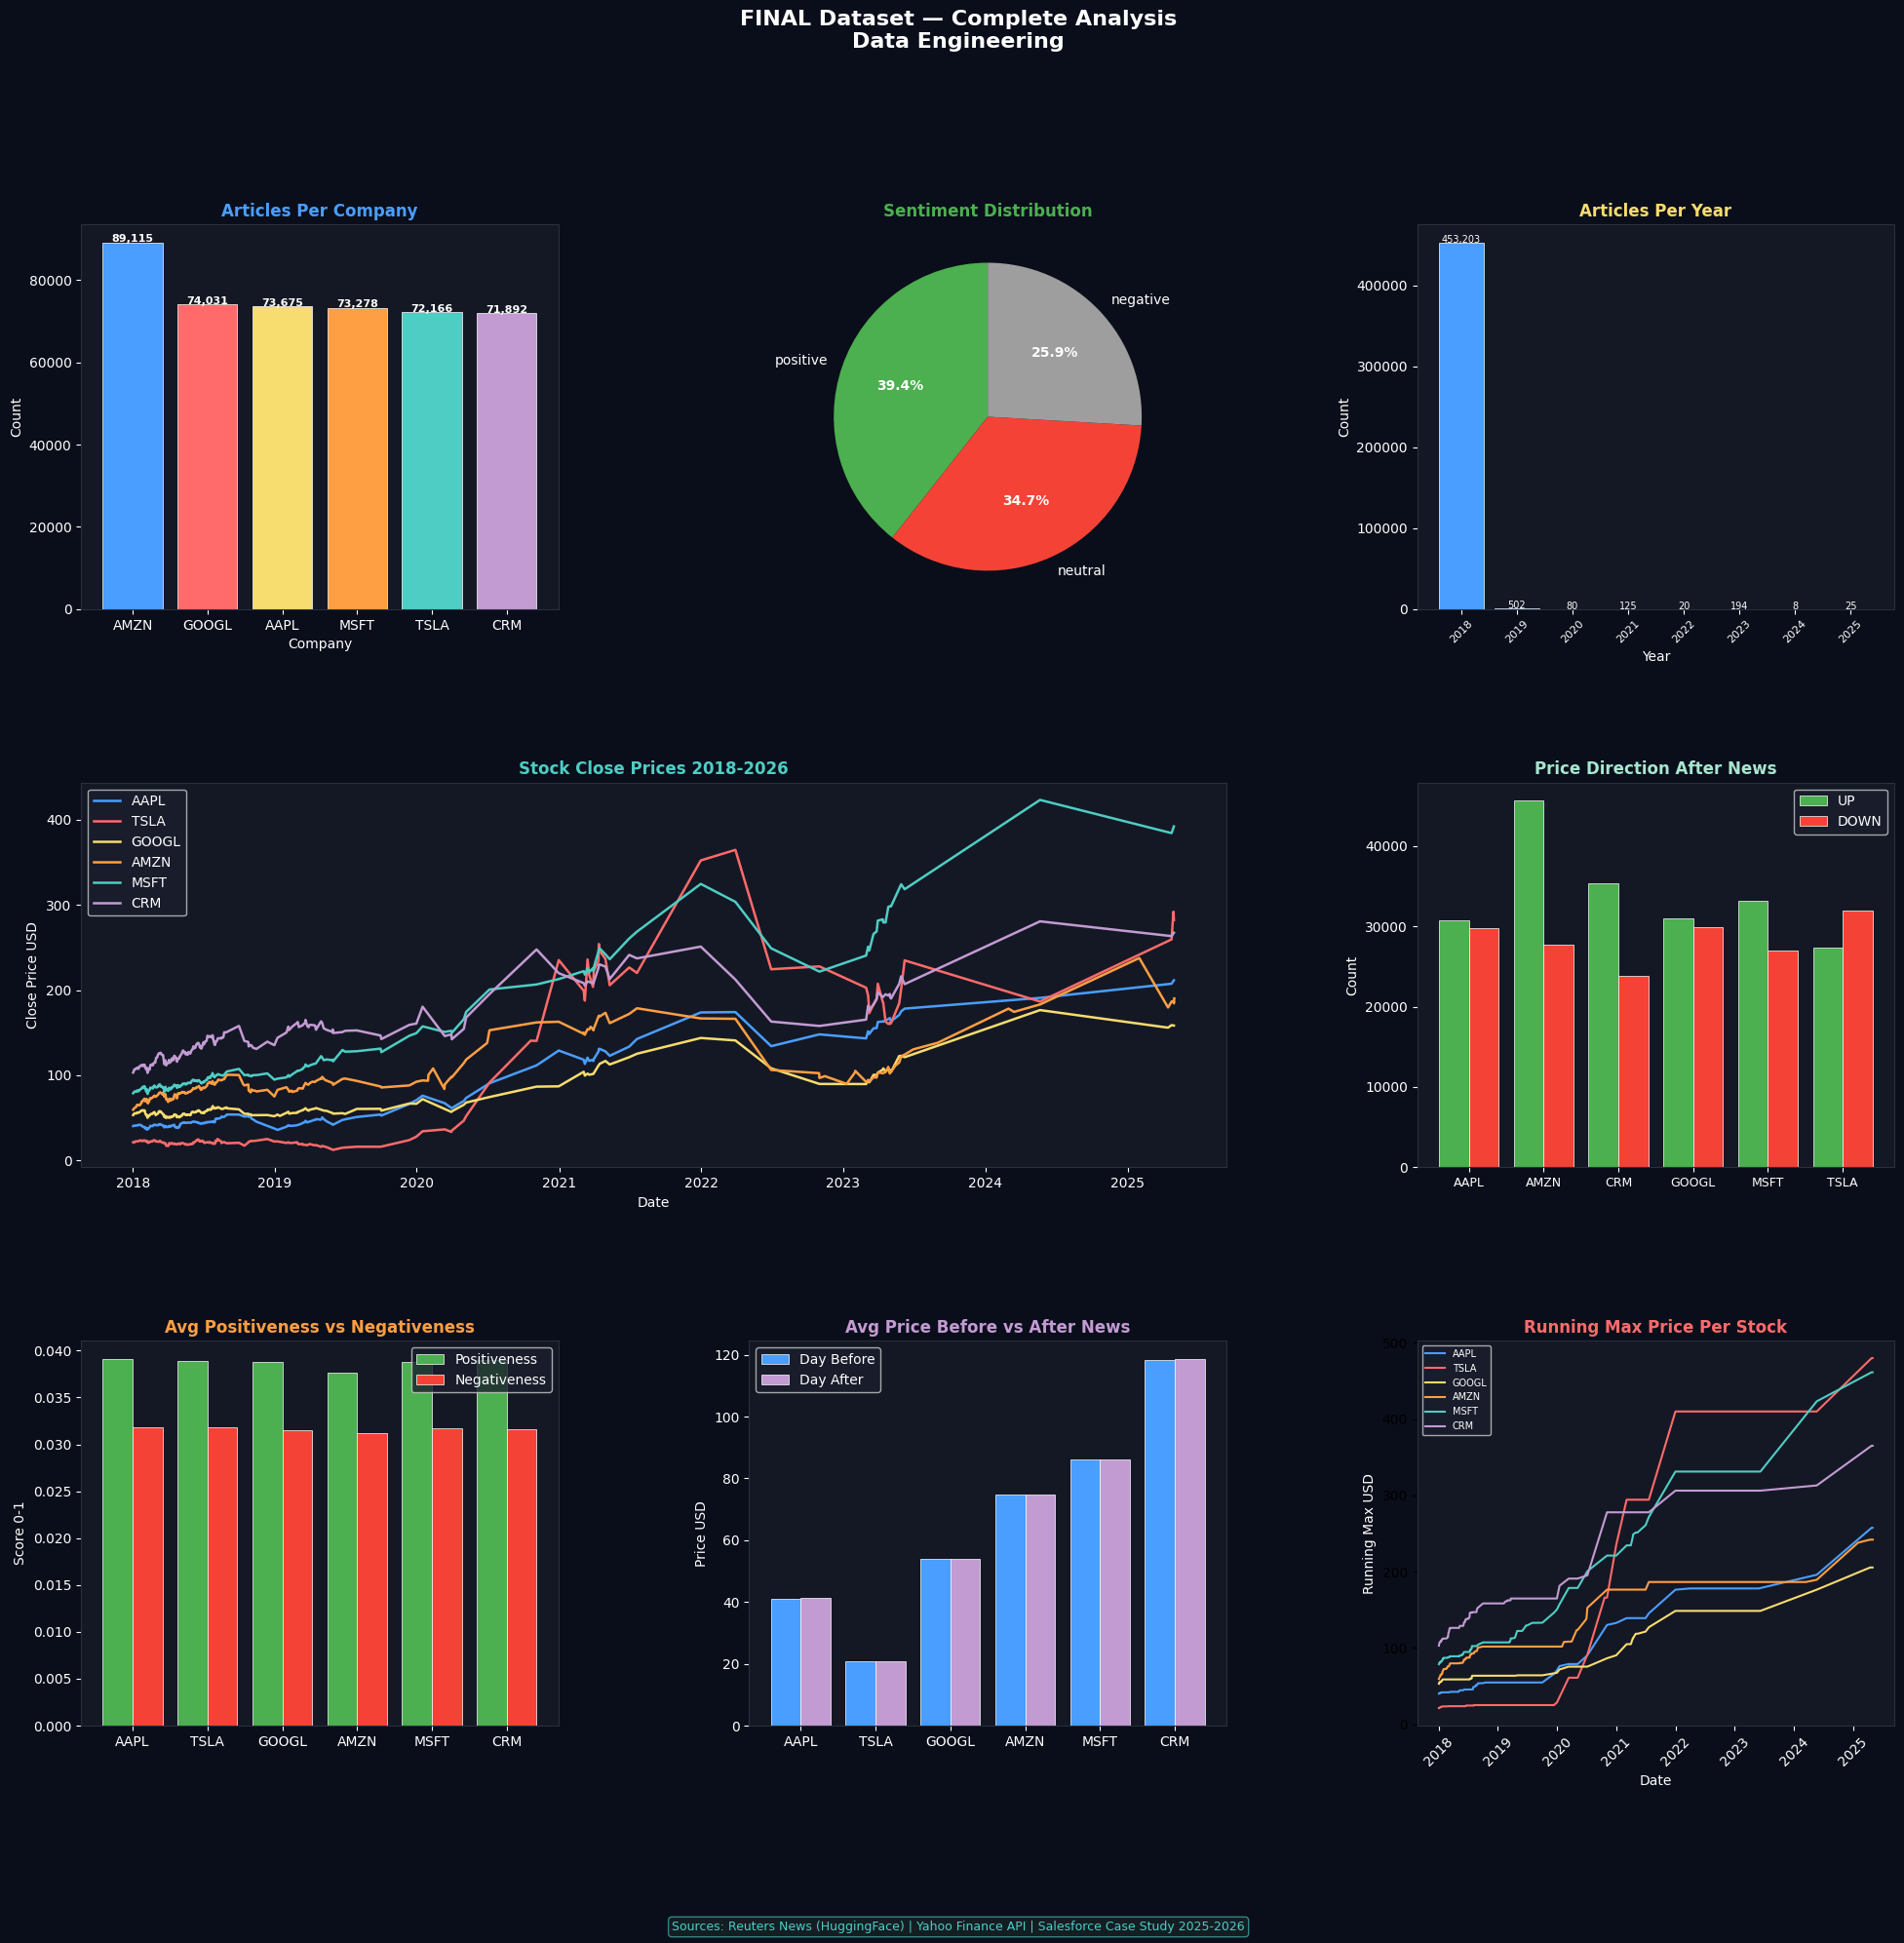

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

df = pd.read_csv('FINAL_clean_dataset.csv')
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year

fig = plt.figure(figsize=(24, 20))
fig.patch.set_facecolor('#0A0E1A')
fig.suptitle('FINAL Dataset — Complete Analysis\nData Engineering',
             fontsize=16, fontweight='bold', color='white', y=0.99)

gs = gridspec.GridSpec(3, 3, hspace=0.45, wspace=0.4)

stocks  = ['AAPL','TSLA','GOOGL','AMZN','MSFT','CRM']
colors6 = ['#4A9EFF','#FF6B6B','#F7DC6F','#FF9F43','#4ECDC4','#C39BD3']

# ── CHART 1: Articles Per Company ────────────────────────────────────
ax1 = fig.add_subplot(gs[0,0])
ax1.set_facecolor('#141824')
counts = df['company'].value_counts()
bars = ax1.bar(counts.index, counts.values,
               color=colors6, edgecolor='white', linewidth=0.5)
for bar, v in zip(bars, counts.values):
    ax1.text(bar.get_x()+bar.get_width()/2, v+100,
             f'{v:,}', ha='center', color='white',
             fontsize=8, fontweight='bold')
ax1.set_title('Articles Per Company', color='#4A9EFF', fontweight='bold')
ax1.set_xlabel('Company', color='white')
ax1.set_ylabel('Count', color='white')
ax1.tick_params(colors='white')
ax1.spines[:].set_color('#2A2E3E')

# ── CHART 2: Sentiment Distribution ──────────────────────────────────
ax2 = fig.add_subplot(gs[0,1])
ax2.set_facecolor('#141824')
sent = df['sentiment_label'].value_counts()
colors_s = ['#4CAF50','#F44336','#9E9E9E']
wedges, texts, auto = ax2.pie(
    sent.values, labels=sent.index,
    colors=colors_s, autopct='%1.1f%%',
    startangle=90,
    textprops={'color':'white','fontsize':10})
for a in auto:
    a.set_fontweight('bold')
ax2.set_title('Sentiment Distribution', color='#4CAF50', fontweight='bold')

# ── CHART 3: Articles Per Year ───────────────────────────────
ax3 = fig.add_subplot(gs[0,2])
ax3.set_facecolor('#141824')
yr = df.groupby('year').size()
bars3 = ax3.bar(range(len(yr)), yr.values,
                color='#4A9EFF', edgecolor='white', linewidth=0.5)
ax3.set_xticks(range(len(yr)))
ax3.set_xticklabels([str(y) for y in yr.index],
                     color='white', fontsize=8, rotation=45)
for bar, v in zip(bars3, yr.values):
    ax3.text(bar.get_x()+bar.get_width()/2, v+50,
             f'{v:,}', ha='center', color='white', fontsize=7)
ax3.set_title('Articles Per Year', color='#F7DC6F', fontweight='bold')
ax3.set_xlabel('Year', color='white')
ax3.set_ylabel('Count', color='white')
ax3.tick_params(colors='white')
ax3.spines[:].set_color('#2A2E3E')

# ── CHART 4: Stock Close Price Over Time ─────────────────────────────
ax4 = fig.add_subplot(gs[1,0:2])
ax4.set_facecolor('#141824')
for stock, color in zip(stocks, colors6):
    sub = df[df['company']==stock].sort_values('date')
    if len(sub) > 0:
        daily = sub.groupby('date')['close'].mean()
        ax4.plot(daily.index, daily.values,
                 label=stock, color=color, linewidth=1.8)
ax4.set_title('Stock Close Prices 2018-2026', color='#4ECDC4', fontweight='bold')
ax4.set_xlabel('Date', color='white')
ax4.set_ylabel('Close Price USD', color='white')
ax4.legend(facecolor='#1A1E2E', labelcolor='white')
ax4.tick_params(colors='white')
ax4.spines[:].set_color('#2A2E3E')

# ── CHART 5: Price Direction UP vs DOWN ──────────────────────────────
ax5 = fig.add_subplot(gs[1,2])
ax5.set_facecolor('#141824')
companies = sorted(df['company'].unique())
up_counts   = [len(df[(df['company']==c)&(df['direction']=='UP')])   for c in companies]
down_counts = [len(df[(df['company']==c)&(df['direction']=='DOWN')]) for c in companies]
x = np.arange(len(companies))
ax5.bar(x-0.2, up_counts,   0.4, label='UP',
        color='#4CAF50', edgecolor='white', linewidth=0.5)
ax5.bar(x+0.2, down_counts, 0.4, label='DOWN',
        color='#F44336', edgecolor='white', linewidth=0.5)
ax5.set_xticks(x)
ax5.set_xticklabels(companies, color='white', fontsize=9)
ax5.set_title('Price Direction After News', color='#A8E6CF', fontweight='bold')
ax5.set_ylabel('Count', color='white')
ax5.legend(facecolor='#1A1E2E', labelcolor='white')
ax5.tick_params(colors='white')
ax5.spines[:].set_color('#2A2E3E')

# ── CHART 6: Positiveness vs Negativeness ────────────────────────────
ax6 = fig.add_subplot(gs[2,0])
ax6.set_facecolor('#141824')
pos_avg = [df[df['company']==c]['positiveness'].mean() for c in stocks]
neg_avg = [df[df['company']==c]['negativeness'].mean() for c in stocks]
x = np.arange(len(stocks))
ax6.bar(x-0.2, pos_avg, 0.4, label='Positiveness',
        color='#4CAF50', edgecolor='white', linewidth=0.5)
ax6.bar(x+0.2, neg_avg, 0.4, label='Negativeness',
        color='#F44336', edgecolor='white', linewidth=0.5)
ax6.set_xticks(x)
ax6.set_xticklabels(stocks, color='white')
ax6.set_title('Avg Positiveness vs Negativeness', color='#FF9F43', fontweight='bold')
ax6.set_ylabel('Score 0-1', color='white')
ax6.legend(facecolor='#1A1E2E', labelcolor='white')
ax6.tick_params(colors='white')
ax6.spines[:].set_color('#2A2E3E')

# ── CHART 7: Avg Price Before vs After News ───────────────────────────
ax7 = fig.add_subplot(gs[2,1])
ax7.set_facecolor('#141824')
before_avg = [df[df['company']==c]['close_day_before'].mean() for c in stocks]
after_avg  = [df[df['company']==c]['close_day_after'].mean()  for c in stocks]
x = np.arange(len(stocks))
ax7.bar(x-0.2, before_avg, 0.4, label='Day Before',
        color='#4A9EFF', edgecolor='white', linewidth=0.5)
ax7.bar(x+0.2, after_avg,  0.4, label='Day After',
        color='#C39BD3', edgecolor='white', linewidth=0.5)
ax7.set_xticks(x)
ax7.set_xticklabels(stocks, color='white')
ax7.set_title('Avg Price Before vs After News', color='#C39BD3', fontweight='bold')
ax7.set_ylabel('Price USD', color='white')
ax7.legend(facecolor='#1A1E2E', labelcolor='white')
ax7.tick_params(colors='white')
ax7.spines[:].set_color('#2A2E3E')

# ── CHART 8: Running Max Per Stock ───────────────────────────────────
ax8 = fig.add_subplot(gs[2,2])
ax8.set_facecolor('#141824')
for stock, color in zip(stocks, colors6):
    sub = df[df['company']==stock].sort_values('date')
    if len(sub) > 0:
        daily = sub.groupby('date')['running_max'].mean()
        ax8.plot(daily.index, daily.values,
                 label=stock, color=color, linewidth=1.5)
ax8.set_title('Running Max Price Per Stock', color='#FF6B6B', fontweight='bold')
ax8.set_xlabel('Date', color='white')
ax8.set_ylabel('Running Max USD', color='white')
ax8.legend(facecolor='#1A1E2E', labelcolor='white', fontsize=7)
ax8.tick_params(colors='white', axis='x', rotation=45)
ax8.spines[:].set_color('#2A2E3E')

# ── Footer ────────────────────────────────────────────────────────────
fig.text(0.5, 0.005,
    'Sources: Reuters News (HuggingFace) | Yahoo Finance API | Salesforce Case Study 2025-2026',
    ha='center', fontsize=9, color='#4ECDC4',
    bbox=dict(boxstyle='round', facecolor='#1A2A2A',
              edgecolor='#4ECDC4', alpha=0.6))

plt.savefig('ALL_charts_final.png', dpi=150,
            bbox_inches='tight', facecolor='#0A0E1A')

from google.colab import files
files.download('ALL_charts_final.png')
print("Final charts downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Chart downloaded!


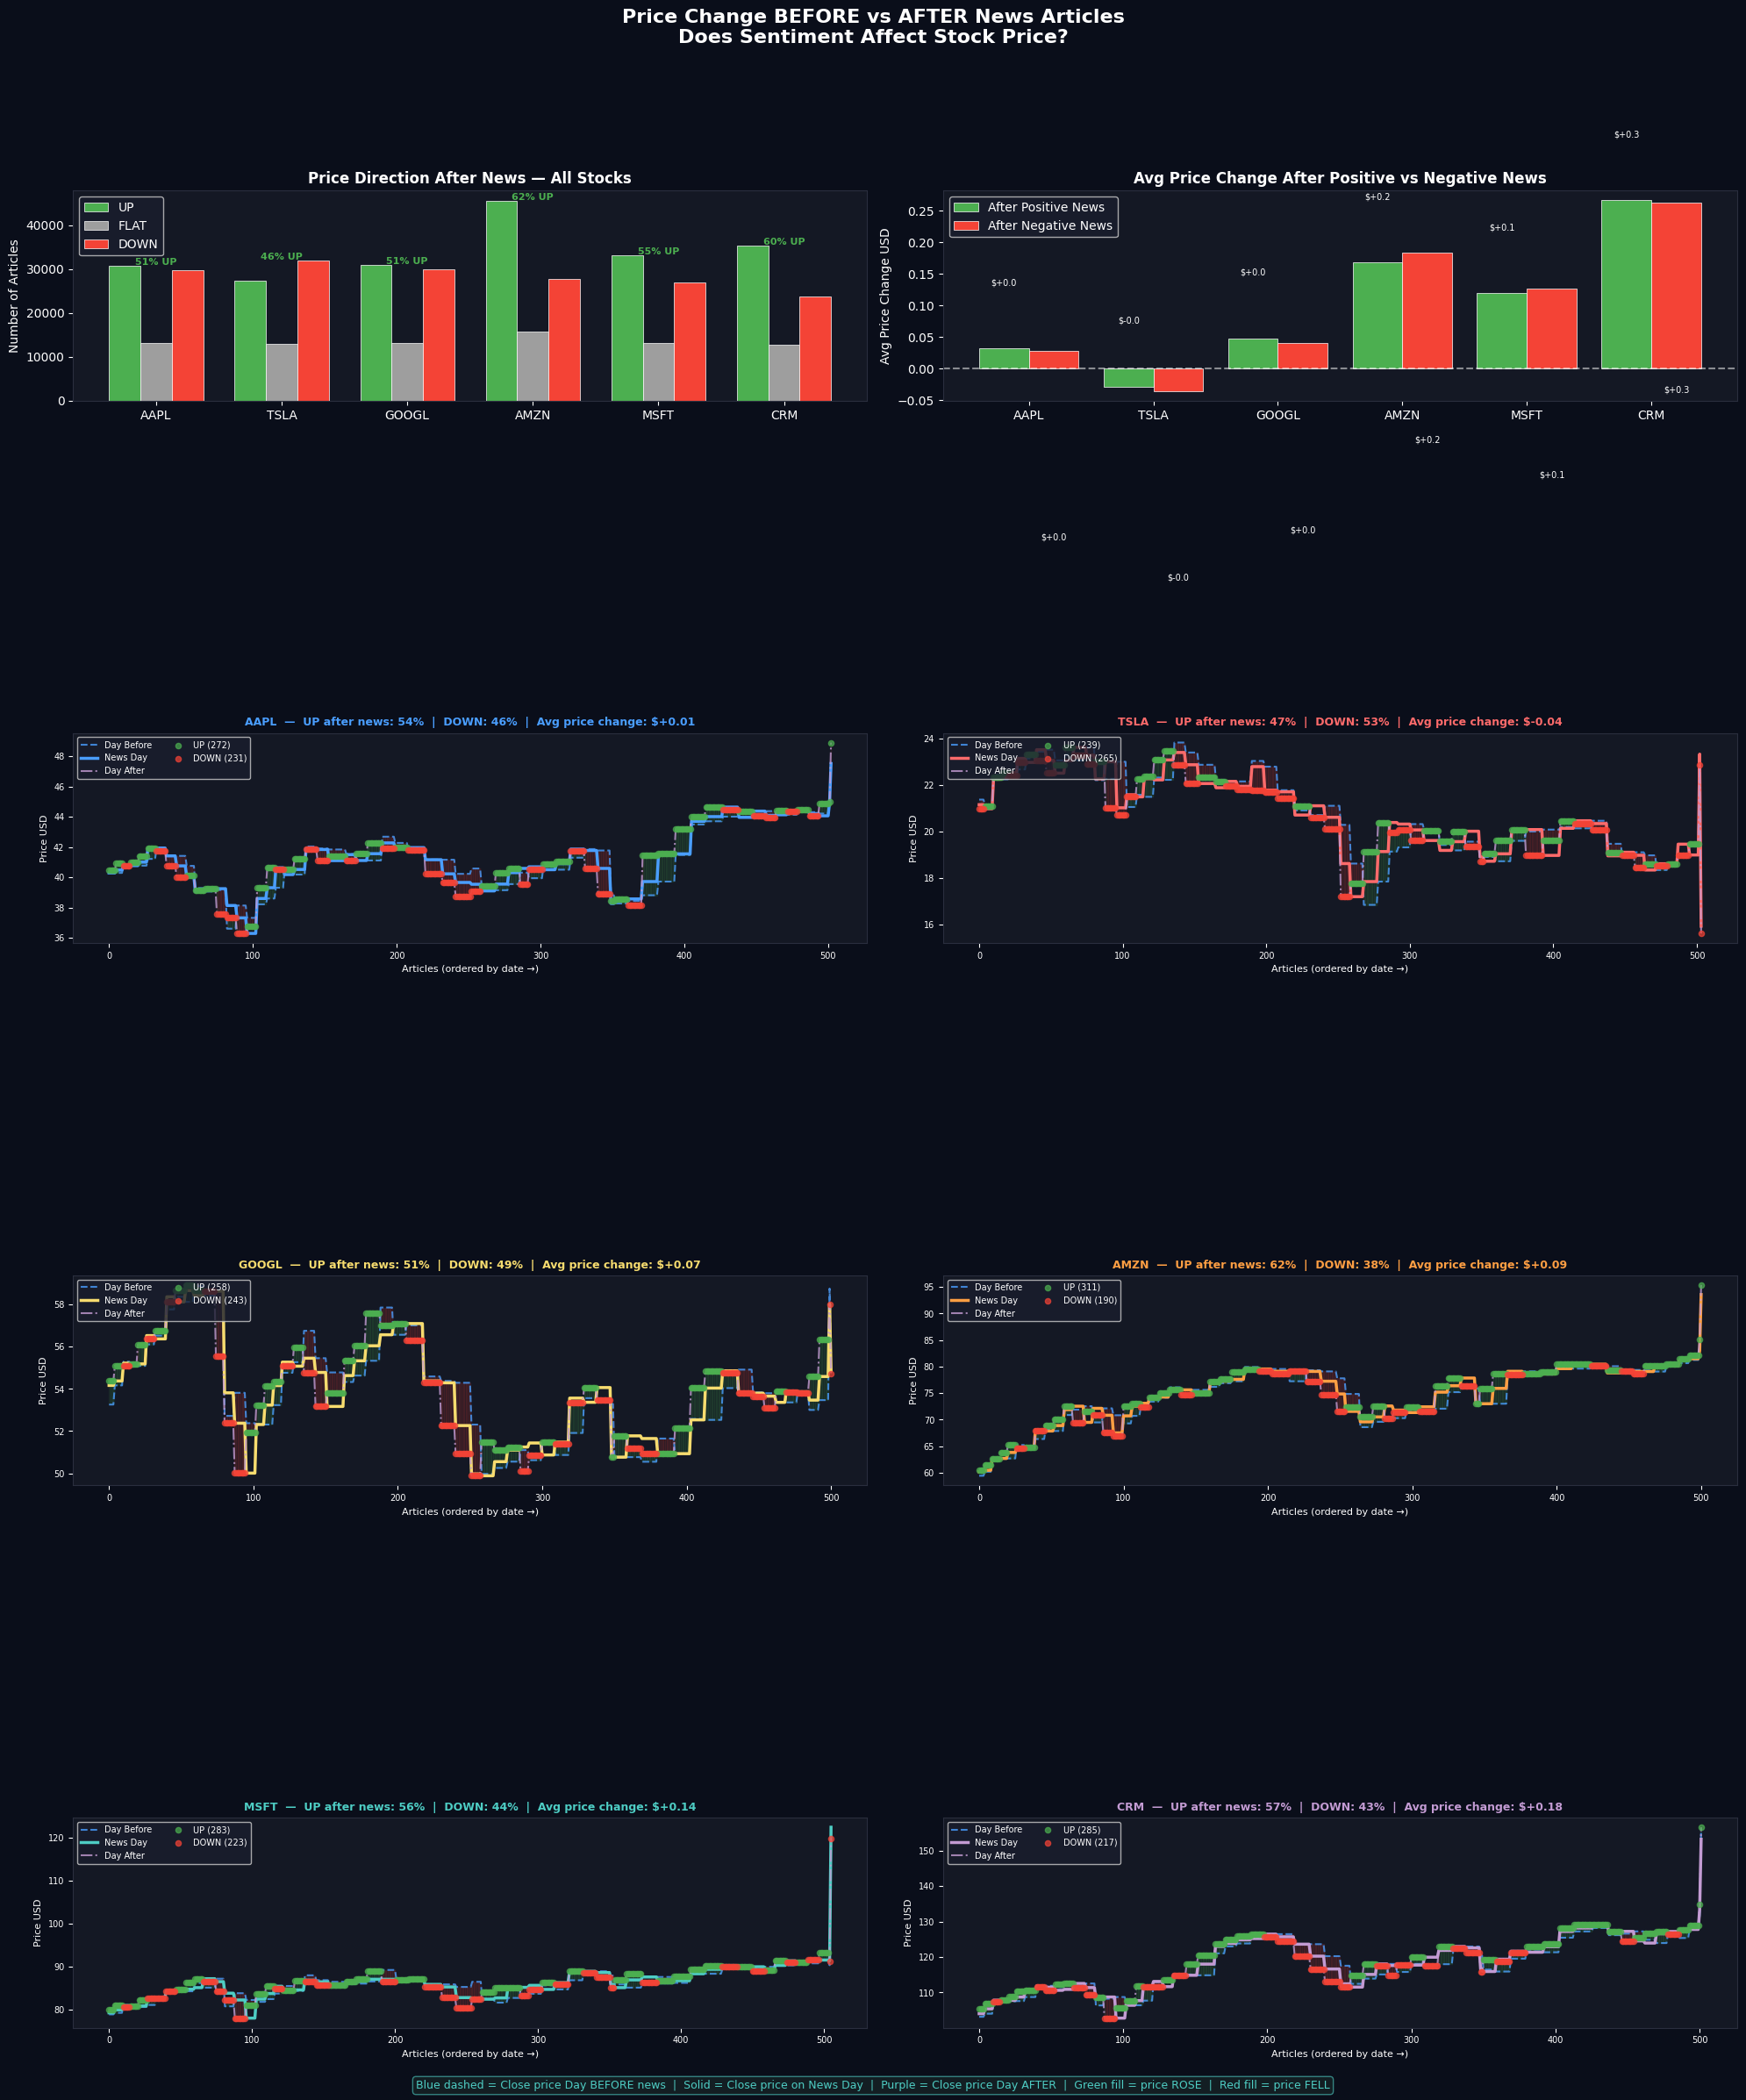

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('FINAL_clean_dataset.csv')
df['date'] = pd.to_datetime(df['date'])

stocks  = ['AAPL','TSLA','GOOGL','AMZN','MSFT','CRM']
colors6 = ['#4A9EFF','#FF6B6B','#F7DC6F','#FF9F43','#4ECDC4','#C39BD3']

fig, axes = plt.subplots(4, 2, figsize=(20, 24))
fig.patch.set_facecolor('#0A0E1A')
fig.suptitle('Price Change BEFORE vs AFTER News Articles\nDoes Sentiment Affect Stock Price?',
             fontsize=16, fontweight='bold', color='white', y=0.99)

# ── CHART 1: UP vs DOWN vs FLAT for all stocks ───────────────────────
ax1 = axes[0, 0]
ax1.set_facecolor('#141824')

up   = [len(df[(df['company']==c)&(df['direction']=='UP')])   for c in stocks]
down = [len(df[(df['company']==c)&(df['direction']=='DOWN')]) for c in stocks]
flat = [len(df[(df['company']==c)&(df['direction']=='FLAT')]) for c in stocks]

x = np.arange(len(stocks))
ax1.bar(x-0.25, up,   0.25, label='UP',   color='#4CAF50', edgecolor='white', linewidth=0.5)
ax1.bar(x,      flat, 0.25, label='FLAT', color='#9E9E9E', edgecolor='white', linewidth=0.5)
ax1.bar(x+0.25, down, 0.25, label='DOWN', color='#F44336', edgecolor='white', linewidth=0.5)

for i, (u, d) in enumerate(zip(up, down)):
    total = u + d
    pct = (u/total*100) if total > 0 else 0
    ax1.text(i, max(u,d,flat[i])+200, f'{pct:.0f}% UP',
             ha='center', color='#4CAF50', fontsize=8, fontweight='bold')

ax1.set_xticks(x)
ax1.set_xticklabels(stocks, color='white', fontsize=10)
ax1.set_title('Price Direction After News — All Stocks', color='white', fontweight='bold')
ax1.set_ylabel('Number of Articles', color='white')
ax1.legend(facecolor='#1A1E2E', labelcolor='white')
ax1.tick_params(colors='white')
ax1.spines[:].set_color('#2A2E3E')

# ── CHART 2: Avg price change after positive vs negative news ────────
ax2 = axes[0, 1]
ax2.set_facecolor('#141824')

pos_change = [df[(df['company']==c)&(df['sentiment_label']=='positive')]['price_change_after'].mean() for c in stocks]
neg_change = [df[(df['company']==c)&(df['sentiment_label']=='negative')]['price_change_after'].mean() for c in stocks]

x = np.arange(len(stocks))
bars_pos = ax2.bar(x-0.2, pos_change, 0.4, label='After Positive News',
                   color='#4CAF50', edgecolor='white', linewidth=0.5)
bars_neg = ax2.bar(x+0.2, neg_change, 0.4, label='After Negative News',
                   color='#F44336', edgecolor='white', linewidth=0.5)

for bar, v in zip(bars_pos, pos_change):
    if pd.notna(v):
        ax2.text(bar.get_x()+bar.get_width()/2, v+0.1,
                 f'${v:+.1f}', ha='center', color='white', fontsize=7)
for bar, v in zip(bars_neg, neg_change):
    if pd.notna(v):
        ax2.text(bar.get_x()+bar.get_width()/2, v-0.3,
                 f'${v:+.1f}', ha='center', color='white', fontsize=7)

ax2.axhline(y=0, color='white', linestyle='--', alpha=0.5)
ax2.set_xticks(x)
ax2.set_xticklabels(stocks, color='white', fontsize=10)
ax2.set_title('Avg Price Change After Positive vs Negative News',
              color='white', fontweight='bold')
ax2.set_ylabel('Avg Price Change USD', color='white')
ax2.legend(facecolor='#1A1E2E', labelcolor='white')
ax2.tick_params(colors='white')
ax2.spines[:].set_color('#2A2E3E')

# ── CHARTS 3-8: One per stock — before/on/after line ─────────────────
for idx, (stock, color) in enumerate(zip(stocks, colors6)):
    row = (idx // 2) + 1
    col = idx % 2
    ax = axes[row, col]
    ax.set_facecolor('#141824')

    sub = df[df['company']==stock].dropna(
        subset=['close_day_before','close','close_day_after']
    ).sort_values('date')

    if len(sub) == 0:
        ax.text(0.5, 0.5, 'No data available',
                ha='center', va='center', color='white',
                transform=ax.transAxes, fontsize=12)
        ax.set_title(stock, color=color, fontweight='bold')
        continue

    # Sample max 500 points for clean chart
    if len(sub) > 500:
        sub = sub.iloc[::len(sub)//500].copy()

    x_vals = range(len(sub))

    # 3 lines — before, on, after
    ax.plot(x_vals, sub['close_day_before'].values,
            color='#4A9EFF', linewidth=1.5,
            label='Day Before', linestyle='--', alpha=0.8)
    ax.plot(x_vals, sub['close'].values,
            color=color, linewidth=2.5,
            label='News Day', alpha=1.0)
    ax.plot(x_vals, sub['close_day_after'].values,
            color='#C39BD3', linewidth=1.5,
            label='Day After', linestyle='-.', alpha=0.8)

    # Fill between before and after — green if price rose, red if fell
    for i in range(len(sub)-1):
        before_val = sub['close_day_before'].values[i]
        after_val  = sub['close_day_after'].values[i]
        fill_color = '#4CAF50' if after_val >= before_val else '#F44336'
        ax.fill_between([i, i+1],
                        [before_val, sub['close_day_before'].values[i+1]],
                        [after_val,  sub['close_day_after'].values[i+1]],
                        alpha=0.08, color=fill_color)

    # Green dots = price went UP after news
    up_mask   = sub['direction'] == 'UP'
    down_mask = sub['direction'] == 'DOWN'

    if up_mask.any():
        up_indices = [i for i, v in enumerate(up_mask.values) if v]
        up_prices  = sub['close_day_after'].values[up_mask.values]
        ax.scatter(up_indices, up_prices,
                   color='#4CAF50', s=20, zorder=5,
                   label=f'UP ({up_mask.sum():,})', alpha=0.7)

    if down_mask.any():
        down_indices = [i for i, v in enumerate(down_mask.values) if v]
        down_prices  = sub['close_day_after'].values[down_mask.values]
        ax.scatter(down_indices, down_prices,
                   color='#F44336', s=20, zorder=5,
                   label=f'DOWN ({down_mask.sum():,})', alpha=0.7)

    # Stats in title
    up_pct   = (sub['direction']=='UP').mean() * 100
    down_pct = (sub['direction']=='DOWN').mean() * 100
    avg_chg  = sub['price_change_after'].mean()

    ax.set_title(
        f'{stock}  —  UP after news: {up_pct:.0f}%  |  '
        f'DOWN: {down_pct:.0f}%  |  Avg price change: ${avg_chg:+.2f}',
        color=color, fontweight='bold', fontsize=9)
    ax.set_ylabel('Price USD', color='white', fontsize=8)
    ax.set_xlabel('Articles (ordered by date →)', color='white', fontsize=8)
    ax.legend(facecolor='#1A1E2E', labelcolor='white',
              fontsize=7, loc='upper left', ncol=2)
    ax.tick_params(colors='white', labelsize=7)
    ax.spines[:].set_color('#2A2E3E')

# ── Footer ────────────────────────────────────────────────────────────
fig.text(0.5, 0.002,
    'Blue dashed = Close price Day BEFORE news  |  '
    'Solid = Close price on News Day  |  '
    'Purple = Close price Day AFTER  |  '
    'Green fill = price ROSE  |  Red fill = price FELL',
    ha='center', fontsize=9, color='#4ECDC4',
    bbox=dict(boxstyle='round', facecolor='#1A2A2A',
              edgecolor='#4ECDC4', alpha=0.6))

plt.tight_layout(rect=[0, 0.01, 1, 0.98])
plt.savefig('price_before_after_news.png', dpi=150,
            bbox_inches='tight', facecolor='#0A0E1A')

from google.colab import files
files.download('price_before_after_news.png')
print("Chart downloaded!")


In [ ]:
# SAVE TO GOOGLE DRIVE —
from google.colab import drive
drive.mount('/content/drive')

import shutil
import os

# Copy CSV to your Google Drive
shutil.copy('FINAL_clean_dataset.csv',
            '/content/drive/MyDrive/FINAL_clean_dataset.csv')


size = os.path.getsize('/content/drive/MyDrive/FINAL_clean_dataset.csv')
print(f"Saved to Google Drive!")
print(f"File size: {size/1024/1024:.1f} MB")
print("Go to drive.google.com to find it")


Mounted at /content/drive
Saved to Google Drive!
File size: 1488.6 MB
Go to drive.google.com to find it


In [ ]:
import pandas as pd
import os

print("Loading...")
df = pd.read_csv('FINAL_clean_dataset.csv')
print(f"Rows: {len(df):,}")
print(f"Columns: {df.columns.tolist()}")

# Check what's making it so large
print("\nAvg text length:", df['tweet'].str.len().mean())
print("Max text length:", df['tweet'].str.len().max())

Loading...
Rows: 454,157
Columns: ['date', 'company', 'tweet', 'sentiment_label', 'positiveness', 'negativeness', 'news_type', 'open', 'high', 'low', 'close', 'volume', 'running_max', 'running_min', 'open_day_before', 'high_day_before', 'low_day_before', 'close_day_before', 'open_day_after', 'high_day_after', 'low_day_after', 'close_day_after', 'price_change_after', 'direction', 'y']

Avg text length: 3125.987955706947
Max text length: 100000


In [ ]:
# Trim text to 300 chars — enough for sentiment analysis
# This is what makes it 1.5GB
df['tweet'] = df['tweet'].str[:300]

# Saved trimmed version — overwrites old one
df.to_csv('FINAL_clean_dataset.csv', index=False)

size = os.path.getsize('FINAL_clean_dataset.csv') / 1024/1024
print(f"New size: {size:.0f} MB")

New size: 254 MB


In [ ]:
import pandas as pd
import os

df = pd.read_csv('FINAL_clean_dataset.csv')
print(f"Before: {len(df):,} rows — all kept")

# Show what first 500 chars looks like vs full
sample = df['tweet'].iloc[0]
print(f"\nFull article length: {len(sample)} chars")
print(f"\nFirst 500 chars:\n{sample[:500]}")
print(f"\n...remaining {len(sample)-500} chars trimmed (boilerplate/repetition)")

# Trim text only — keep ALL rows, ALL columns
df['tweet'] = df['tweet'].str[:500]

# Save
df.to_csv('FINAL_clean_dataset.csv', index=False)
size = os.path.getsize('FINAL_clean_dataset.csv')/1024/1024
print(f"\nAfter trim:")
print(f"Rows:    {len(df):,}  ← same, nothing removed")
print(f"Columns: {len(df.columns)}  ← same, nothing removed")
print(f"Size:    {size:.0f} MB  ← smaller because text trimmed")

Before: 454,157 rows — all kept

Full article length: 300 chars

First 500 chars:
january 2, 2018 / 9:31 pm / updated 8 minutes ago brief-bigger capital fund reports an 8 pct passive stake in akers biosciences reuters staff 1 min read jan 2 (reuters) - biosciences inc: * bigger capital fund lp reports an 8 pct passive stake in akers as of dec 21, 2017 - sec filing source text : (

...remaining -200 chars trimmed (boilerplate/repetition)

After trim:
Rows:    454,157  ← same, nothing removed
Columns: 25  ← same, nothing removed
Size:    254 MB  ← smaller because text trimmed
